# 02 - EDA Deep Dive (EDA2)

This notebook **re-runs the full cleaning pipeline self-contained** (so every cell produces output,
including sections 5-7 that did not render in `01_eda.ipynb`) and then adds **new deeper analysis**.

**Reproduced (now with output):**
- Section 5: Severity & violation-type EDA + co-occurrence + weight calibration
- Section 6: Device / reporter EDA + rejection rates

**New analysis (the "study more" part):**
- A. Repeat-offender deep dive (frequency, mobility, hotspot loyalty)
- B. Spatio-temporal cross-analysis (when do top hotspots fire?)
- C. Validation / enforcement-quality deep dive (what gets rejected)
- D. Risk-score component simulation (severity x vehicle x density per location)
- E. POI / junction spillover analysis
- F. The afternoon "blind spot" - logging coverage vs demand

## 0. Setup - load + full cleaning pipeline (self-contained)

In [1]:
import sys, ast, json, re
from pathlib import Path
from itertools import combinations
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pytz

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')
IST = pytz.timezone('Asia/Kolkata')

ROOT = Path().resolve().parent
RAW_CSV = ROOT / 'data' / 'raw' / 'violations.csv'
df = pd.read_csv(RAW_CSV, low_memory=False)
print(f'Loaded raw: {df.shape}')

Loaded raw: (298450, 24)


In [2]:
# ---- Array column parsing ----
def safe_parse_list(val):
    if pd.isna(val):
        return []
    s = str(val).strip()
    for candidate in [s, s.replace('""', '"')]:
        for parser in (json.loads, ast.literal_eval):
            try:
                r = parser(candidate)
                return r if isinstance(r, list) else [r]
            except Exception:
                pass
    return [s]

df['vtype_list']    = df['violation_type'].apply(safe_parse_list)
df['primary_vtype'] = df['vtype_list'].apply(lambda l: l[0].upper().strip() if l else None)

# ---- Datetimes -> IST ----
for col in ['created_datetime', 'modified_datetime', 'validation_timestamp']:
    df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')
df['created_at_ist'] = df['created_datetime'].dt.tz_convert(IST)
df['hour']        = df['created_at_ist'].dt.hour
df['day_of_week'] = df['created_at_ist'].dt.dayofweek
df['month']       = df['created_at_ist'].dt.month
df['date']        = df['created_at_ist'].dt.normalize()
df['is_weekend']  = df['day_of_week'].isin([5, 6])

# ---- Canonical vehicle type ----
df['vehicle_canon'] = (df['updated_vehicle_type'].fillna(df['vehicle_type'])
                       .str.upper().str.strip())

# ---- Normalised validation status ----
df['vs_norm'] = df['validation_status'].str.lower().str.strip()

# ---- Junction flag ----
no_jn = df['junction_name'].isna() | df['junction_name'].str.strip().str.upper().eq('NO JUNCTION')
df['has_junction'] = ~no_jn

# ---- Coordinates + in-bbox filter ----
LAT_MIN, LAT_MAX = 12.7, 13.2
LNG_MIN, LNG_MAX = 77.4, 77.8
df['lat'] = pd.to_numeric(df['latitude'],  errors='coerce')
df['lng'] = pd.to_numeric(df['longitude'], errors='coerce')
df_v = df[df['lat'].between(LAT_MIN, LAT_MAX) & df['lng'].between(LNG_MIN, LNG_MAX)].copy()

DOW = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print(f'Clean in-bbox rows (df_v): {len(df_v):,}')
print(f'Date range (IST): {df_v.created_at_ist.min()} -> {df_v.created_at_ist.max()}')

Clean in-bbox rows (df_v): 298,282
Date range (IST): 2023-11-10 00:41:46+05:30 -> 2024-04-08 23:00:46+05:30


## 5. Severity & violation-type EDA  *(reproduced - now renders)*

Unique violation types: 25
vtype_list
WRONG PARKING                                 164920
NO PARKING                                    138932
PARKING IN A MAIN ROAD                         23923
DEFECTIVE NUMBER PLATE                          7843
PARKING ON FOOTPATH                             3757
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC         2398
DOUBLE PARKING                                  2037
PARKING NEAR ROAD CROSSING                      1687
REFUSE TO GO FOR HIRE                            887
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS        525
PARKING OPPOSITE TO ANOTHER PARKED VEHICLE       486
USING BLACK FILM/OTHER MATERIALS                 248
PARKING OTHER THAN BUS STOP                      242
DEMANDING EXCESS FARE                            239
WITHOUT SIDE MIRROR                               47
H T V PROHIBITED                                  27
OBSTRUCTING DRIVER                                16
FAIL TO USE SAFETY BELTS                           8
AGAINST 

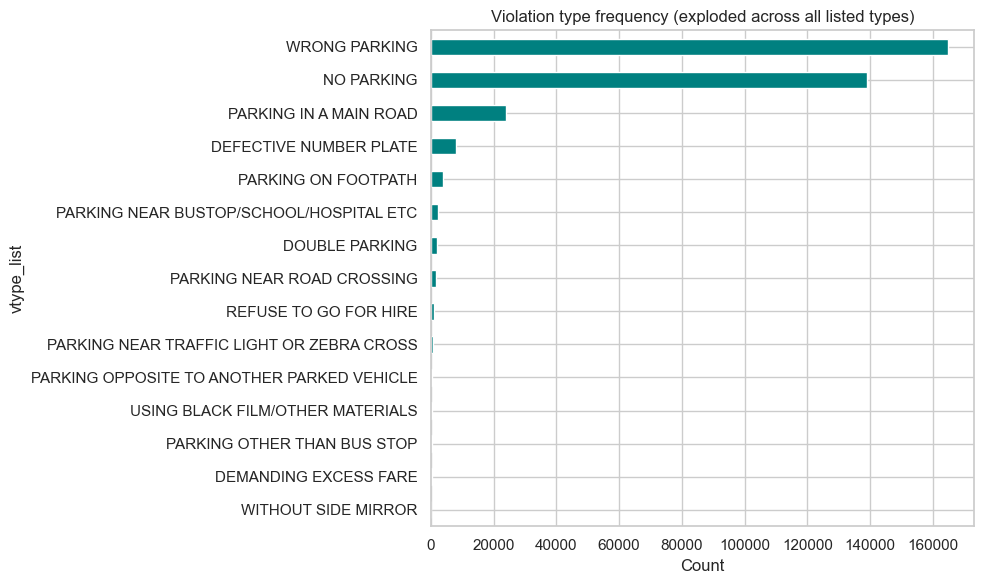

In [3]:
vte = df_v['vtype_list'].explode().dropna()
vte = vte[vte.str.strip() != '']
vtype_vc = vte.str.upper().str.strip().value_counts()
print(f'Unique violation types: {vtype_vc.shape[0]}')
print(vtype_vc.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
vtype_vc.head(15).sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title('Violation type frequency (exploded across all listed types)')
ax.set_xlabel('Count')
plt.tight_layout(); plt.show()

### 5b. Co-occurrence of violation types

Top 15 co-occurring pairs:
                                 type_a                                  type_b  count
                 PARKING IN A MAIN ROAD                           WRONG PARKING  15641
                             NO PARKING                  PARKING IN A MAIN ROAD  11263
                             NO PARKING                           WRONG PARKING   5570
                 DEFECTIVE NUMBER PLATE                           WRONG PARKING   4769
                 DEFECTIVE NUMBER PLATE                              NO PARKING   3337
                    PARKING ON FOOTPATH                           WRONG PARKING   2558
                             NO PARKING                     PARKING ON FOOTPATH   1908
                             NO PARKING PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC   1566
                         DOUBLE PARKING                           WRONG PARKING   1400
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC                           WRONG PARKING   1325
                

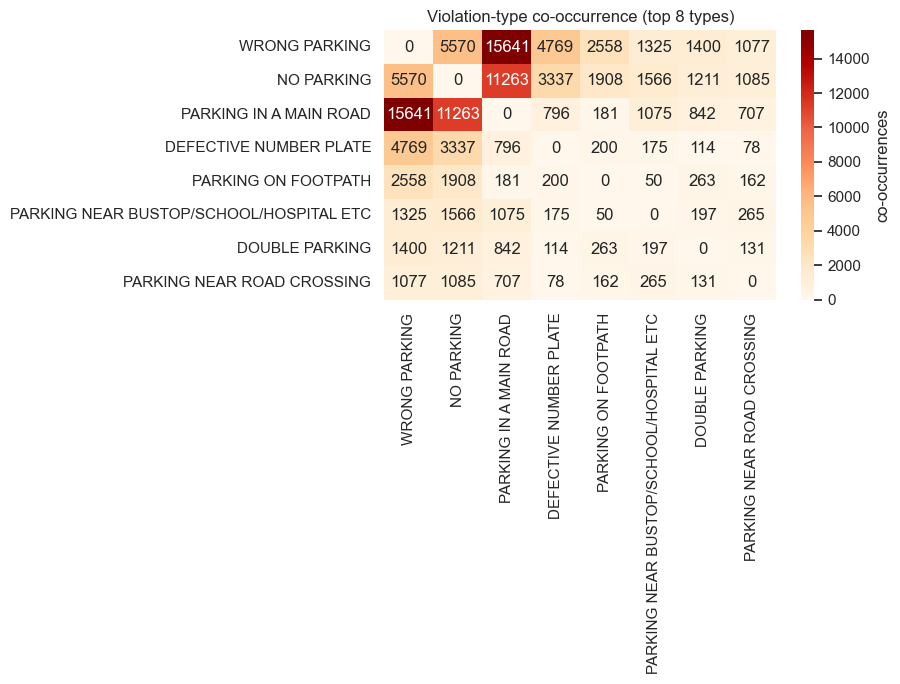

In [4]:
co = {}
for vlist in df_v['vtype_list']:
    cleaned = list({v.upper().strip() for v in vlist if v.strip()})
    if len(cleaned) > 1:
        for a, b in combinations(sorted(cleaned), 2):
            co[(a, b)] = co.get((a, b), 0) + 1
co_df = (pd.DataFrame([(a, b, n) for (a, b), n in co.items()], columns=['type_a', 'type_b', 'count'])
         .sort_values('count', ascending=False))
print('Top 15 co-occurring pairs:')
print(co_df.head(15).to_string(index=False))

top_types = vtype_vc.head(8).index.tolist()
mat = pd.DataFrame(0, index=top_types, columns=top_types)
for (a, b), n in co.items():
    if a in top_types and b in top_types:
        mat.loc[a, b] = n; mat.loc[b, a] = n
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat, annot=True, fmt='d', cmap='OrRd', ax=ax, cbar_kws={'label': 'co-occurrences'})
ax.set_title('Violation-type co-occurrence (top 8 types)')
plt.tight_layout(); plt.show()

### 5c. Severity weight calibration  *(checks config.py coverage)*

In [5]:
SEVERITY_WEIGHTS = {
    'PARKING IN A MAIN ROAD': 3.0, 'PARKING NEAR ROAD CROSSING': 2.5,
    'PARKING ON FOOTPATH': 2.0, 'WRONG PARKING': 1.5, 'NO PARKING': 1.0,
}
DEFAULT_S = 1.0
df_v['severity_w'] = df_v['primary_vtype'].map(lambda v: SEVERITY_WEIGHTS.get(v, DEFAULT_S) if pd.notna(v) else DEFAULT_S)

sw = (df_v.groupby('primary_vtype')
      .agg(count=('id', 'count'), weight=('severity_w', 'first'))
      .sort_values('count', ascending=False))
print('Severity weight coverage:')
print(sw.to_string())
missing_sw = sw[sw['weight'] == DEFAULT_S]
if len(missing_sw):
    print(f'\nWARNING: {len(missing_sw)} types fall back to DEFAULT weight -- consider adding to config.py:')
    print(missing_sw['count'].to_string())
else:
    print('\nOK: all violation types have explicit weights.')

Severity weight coverage:
                                             count  weight
primary_vtype                                             
WRONG PARKING                               147446     1.5
NO PARKING                                  128522     1.0
PARKING IN A MAIN ROAD                       17069     3.0
PARKING ON FOOTPATH                           2447     2.0
DEFECTIVE NUMBER PLATE                         807     1.0
PARKING NEAR ROAD CROSSING                     646     2.5
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC        594     1.0
DOUBLE PARKING                                 316     1.0
PARKING OTHER THAN BUS STOP                    194     1.0
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS      125     1.0
PARKING OPPOSITE TO ANOTHER PARKED VEHICLE      67     1.0
H T V PROHIBITED                                25     1.0
REFUSE TO GO FOR HIRE                           18     1.0
WITHOUT SIDE MIRROR                              3     1.0
OBSTRUCTING DRIVER            

## 6. Device / reporter EDA  *(reproduced - now renders)*

Unique device_id     : 3,056
Unique created_by_id : 2,651


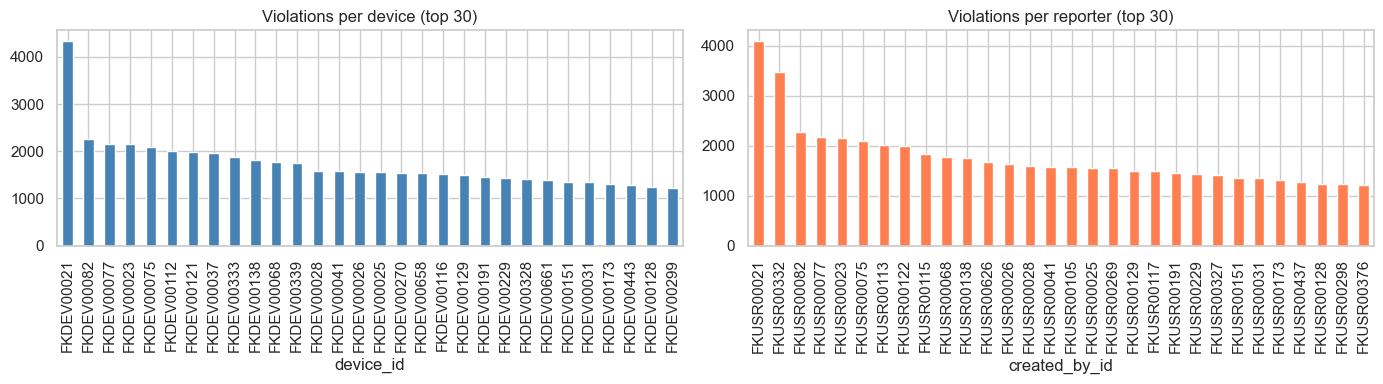

Top device share   : 1.5%
Top reporter share : 1.4%
Top 10 devices account for: 7.6% of all logging


In [6]:
print(f'Unique device_id     : {df_v["device_id"].nunique():,}')
print(f'Unique created_by_id : {df_v["created_by_id"].nunique():,}')
dev_vc = df_v['device_id'].value_counts()
usr_vc = df_v['created_by_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dev_vc.head(30).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Violations per device (top 30)'); axes[0].tick_params(axis='x', rotation=90)
usr_vc.head(30).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Violations per reporter (top 30)'); axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()
print(f'Top device share   : {dev_vc.iloc[0] / len(df_v) * 100:.1f}%')
print(f'Top reporter share : {usr_vc.iloc[0] / len(df_v) * 100:.1f}%')
print(f'Top 10 devices account for: {dev_vc.head(10).sum() / len(df_v) * 100:.1f}% of all logging')

### 6b. Rejection rate by device and station

Rows with a validation decision: 173,116  (58.0%)

Rejection rate by device (>=50 validated, top 10):
            total  rejected  rejection_rate
device_id                                  
FKDEV02236  122.0     106.0          0.8689
FKDEV00057   77.0      61.0          0.7922
FKDEV01089   73.0      54.0          0.7397
FKDEV00838  140.0     102.0          0.7286
FKDEV00529   54.0      39.0          0.7222
FKDEV02601  122.0      88.0          0.7213
FKDEV02269  109.0      77.0          0.7064
FKDEV01314  182.0     128.0          0.7033
FKDEV00289   64.0      45.0          0.7031
FKDEV00538   90.0      62.0          0.6889

Rejection rate by station (top 15):
                      total  rejected  rejection_rate
police_station                                       
Kodigehalli          4172.0    1664.0          0.3988
Madiwala              808.0     311.0          0.3849
K.G. Halli            558.0     214.0          0.3835
Byatarayanapura      2794.0    1041.0          0.3726
No Police

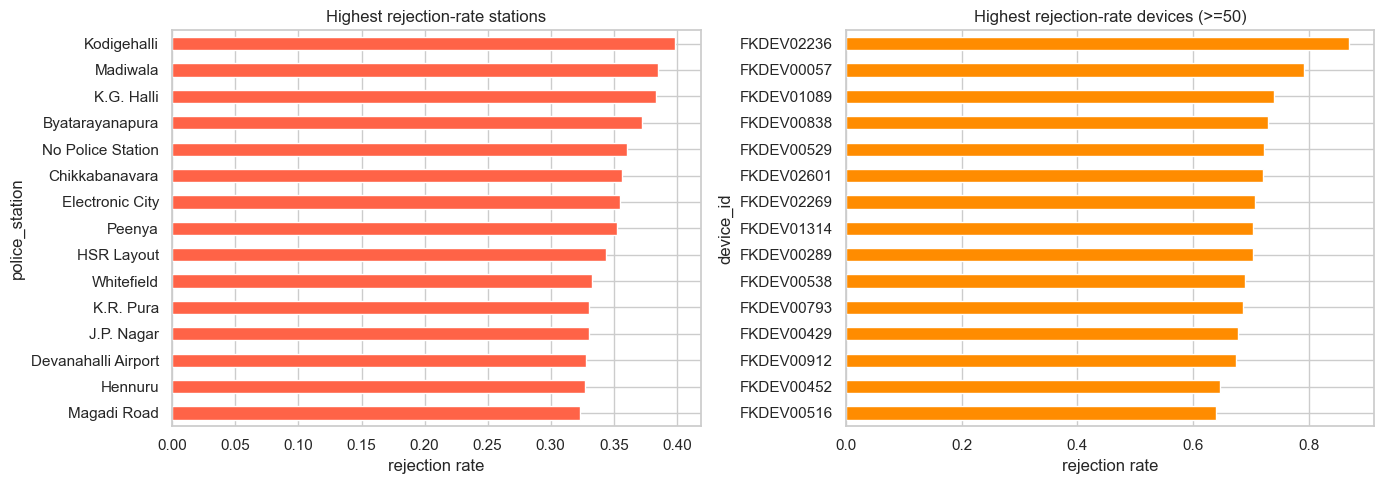

In [7]:
validated = df_v.dropna(subset=['vs_norm'])
print(f'Rows with a validation decision: {len(validated):,}  ({len(validated) / len(df_v) * 100:.1f}%)')

def rej_stats(g):
    t = len(g); r = (g['vs_norm'] == 'rejected').sum()
    return pd.Series({'total': t, 'rejected': r, 'rejection_rate': round(r / t, 4)})

rej_dev = (validated.groupby('device_id').apply(rej_stats)
           .query('total >= 50').sort_values('rejection_rate', ascending=False))
rej_stn = (validated.groupby('police_station').apply(rej_stats)
           .sort_values('rejection_rate', ascending=False))
print('\nRejection rate by device (>=50 validated, top 10):')
print(rej_dev.head(10).to_string())
print('\nRejection rate by station (top 15):')
print(rej_stn.head(15).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rej_stn.sort_values('rejection_rate')['rejection_rate'].tail(15).plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Highest rejection-rate stations'); axes[0].set_xlabel('rejection rate')
rej_dev.sort_values('rejection_rate')['rejection_rate'].tail(15).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Highest rejection-rate devices (>=50)'); axes[1].set_xlabel('rejection rate')
plt.tight_layout(); plt.show()

---
# NEW DEEP-DIVE ANALYSIS
Everything below is additional study beyond `01_eda.ipynb`.

## A. Repeat-offender deep dive
Plates are synthetic (`FKN*`) so identity is anonymised, but **frequency behaviour is real**.
Question: are repeat offenders *mobile* (many locations) or *anchored* (one chronic spot)?

Unique plates           : 231,736
Plates with >=  2 hits :  35,575  (15.4%)
Plates with >=  3 hits :  11,852  ( 5.1%)
Plates with >=  5 hits :   3,489  ( 1.5%)
Plates with >= 10 hits :     711  ( 0.3%)


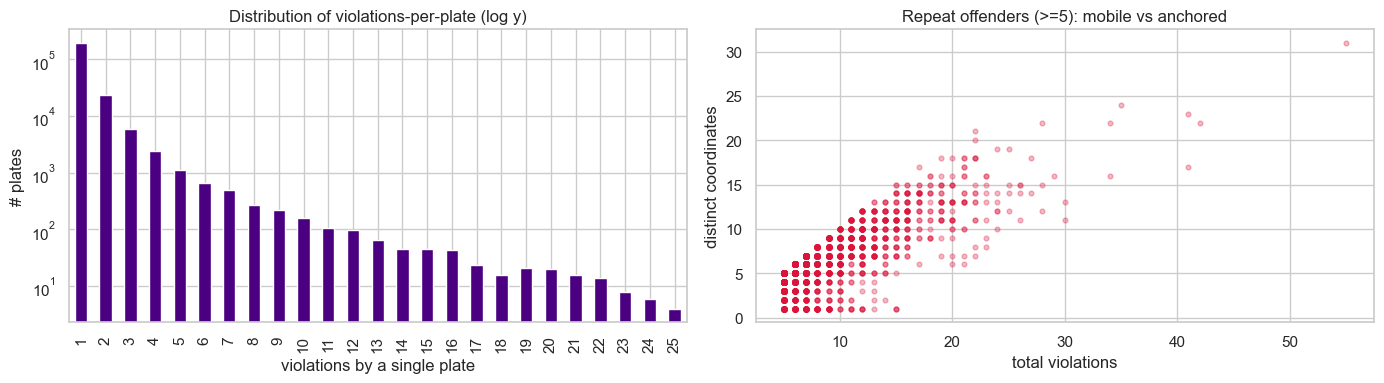


Most ANCHORED chronic offenders (high hits, few coords):
                hits  distinct_locs  distinct_coords  loc_loyalty
vehicle_number                                                   
FKN00GL26490      15              1                1         15.0
FKN00GL26501      15              1                1         15.0
FKN00GL26521      15              1                1         15.0
FKN00GL26488      13              1                1         13.0
FKN00GL26489      12              1                1         12.0
FKN00GL54129      12              1                1         12.0
FKN00GL54146      12              1                1         12.0
FKN00GL54162      12              1                1         12.0
FKN00GL54124      11              1                1         11.0
FKN00GL65696      11              1                1         11.0


In [8]:
plate_vc = df_v['vehicle_number'].value_counts()
print(f'Unique plates           : {plate_vc.shape[0]:,}')
for k in (2, 3, 5, 10):
    n = (plate_vc >= k).sum()
    print(f'Plates with >= {k:>2} hits : {n:>7,}  ({n / plate_vc.shape[0] * 100:4.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plate_vc.value_counts().sort_index().head(25).plot(kind='bar', ax=axes[0], color='indigo', logy=True)
axes[0].set_title('Distribution of violations-per-plate (log y)')
axes[0].set_xlabel('violations by a single plate'); axes[0].set_ylabel('# plates')

repeat = plate_vc[plate_vc >= 5].index
rep_df = df_v[df_v['vehicle_number'].isin(repeat)].copy()
rep_df['coord'] = rep_df['lat'].round(4).astype(str) + ',' + rep_df['lng'].round(4).astype(str)
mobility = rep_df.groupby('vehicle_number').agg(
    hits=('id', 'count'),
    distinct_locs=('location', 'nunique'),
    distinct_coords=('coord', 'nunique'),
)
mobility['loc_loyalty'] = (mobility['hits'] / mobility['distinct_coords']).round(2)
axes[1].scatter(mobility['hits'], mobility['distinct_coords'], alpha=0.3, color='crimson', s=12)
axes[1].set_xlabel('total violations'); axes[1].set_ylabel('distinct coordinates')
axes[1].set_title('Repeat offenders (>=5): mobile vs anchored')
plt.tight_layout(); plt.show()

print('\nMost ANCHORED chronic offenders (high hits, few coords):')
print(mobility.sort_values(['loc_loyalty', 'hits'], ascending=False).head(10).to_string())

## B. Spatio-temporal cross-analysis
For the busiest coordinates (proxy fixed cameras), *when* do violations fire?
Tells a commander the hour-block to deploy at each chronic spot.

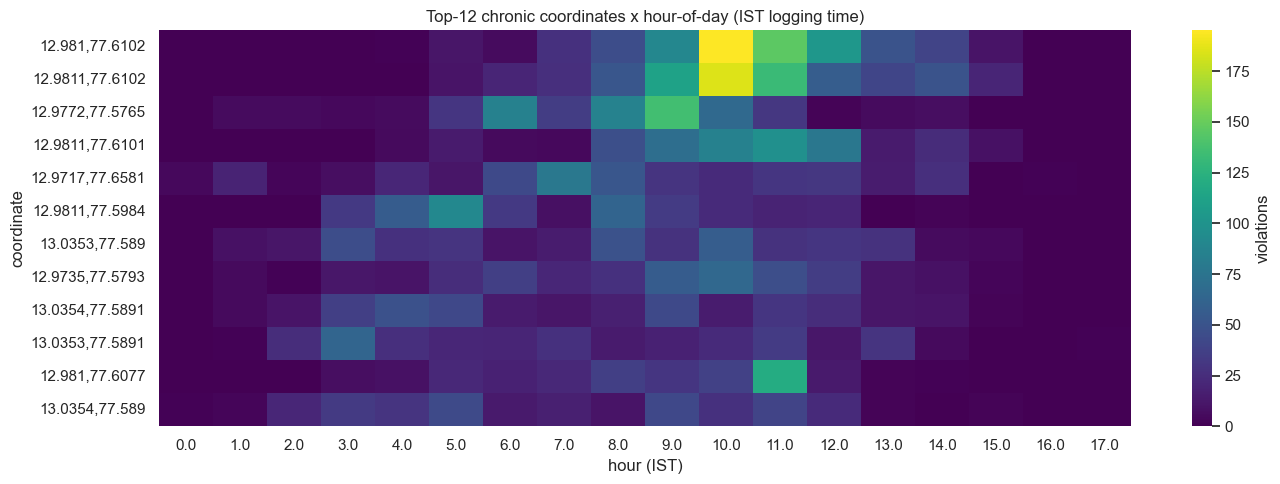

Peak logging hour per chronic coordinate:
coord
12.981,77.6102     10.0
12.9811,77.6102    10.0
12.9772,77.5765     9.0
12.9811,77.6101    11.0
12.9717,77.6581     7.0
12.9811,77.5984     5.0
13.0353,77.589     10.0
12.9735,77.5793    10.0
13.0354,77.5891     4.0
13.0353,77.5891     3.0
12.981,77.6077     11.0
13.0354,77.589      5.0


In [9]:
df_v['coord'] = df_v['lat'].round(4).astype(str) + ',' + df_v['lng'].round(4).astype(str)
top_coords = df_v['coord'].value_counts().head(12).index.tolist()
sub = df_v[df_v['coord'].isin(top_coords)]

pivot = sub.groupby(['coord', 'hour']).size().unstack(fill_value=0).reindex(top_coords)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='viridis', ax=ax, cbar_kws={'label': 'violations'})
ax.set_title('Top-12 chronic coordinates x hour-of-day (IST logging time)')
ax.set_xlabel('hour (IST)'); ax.set_ylabel('coordinate')
plt.tight_layout(); plt.show()

peak_by_coord = sub.groupby('coord')['hour'].agg(lambda s: s.value_counts().idxmax())
print('Peak logging hour per chronic coordinate:')
print(peak_by_coord.reindex(top_coords).to_string())

## C. Validation / enforcement-quality deep dive
What *types* and *vehicles* get rejected most? Rejection is a data-quality signal.

Overall rejection rate: 28.7 %


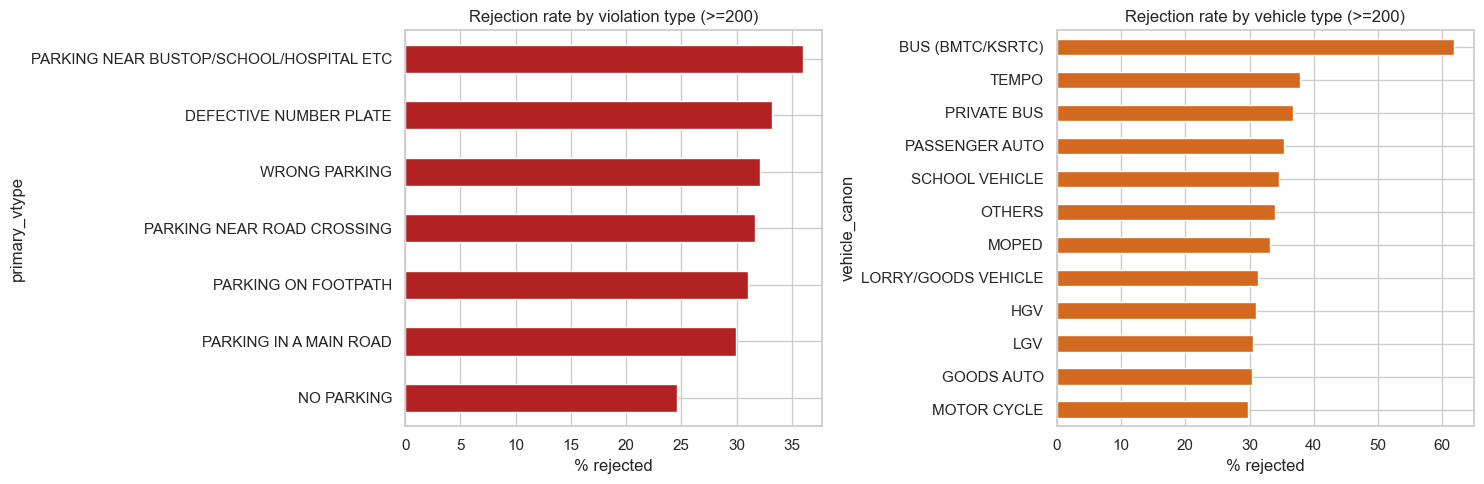


By violation type:
                                         total  rej_rate
primary_vtype                                           
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC    403     0.360
DEFECTIVE NUMBER PLATE                     515     0.332
WRONG PARKING                            85224     0.321
PARKING NEAR ROAD CROSSING                 445     0.317
PARKING ON FOOTPATH                       1348     0.310
PARKING IN A MAIN ROAD                    8951     0.300
NO PARKING                               75783     0.246


In [10]:
val = df_v.dropna(subset=['vs_norm']).copy()
val['rejected'] = (val['vs_norm'] == 'rejected').astype(int)
print('Overall rejection rate:', round(val['rejected'].mean() * 100, 1), '%')

rej_by_vtype = (val.groupby('primary_vtype')
                .agg(total=('id', 'count'), rej_rate=('rejected', 'mean'))
                .query('total>=200').sort_values('rej_rate', ascending=False))
rej_by_veh = (val.groupby('vehicle_canon')
              .agg(total=('id', 'count'), rej_rate=('rejected', 'mean'))
              .query('total>=200').sort_values('rej_rate', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
(rej_by_vtype['rej_rate'] * 100).head(12).sort_values().plot(kind='barh', ax=axes[0], color='firebrick')
axes[0].set_title('Rejection rate by violation type (>=200)'); axes[0].set_xlabel('% rejected')
(rej_by_veh['rej_rate'] * 100).head(12).sort_values().plot(kind='barh', ax=axes[1], color='chocolate')
axes[1].set_title('Rejection rate by vehicle type (>=200)'); axes[1].set_xlabel('% rejected')
plt.tight_layout(); plt.show()
print('\nBy violation type:'); print(rej_by_vtype.round(3).to_string())

## D. Risk-score component simulation
Apply the production formula (config.py weights) at the **coordinate** level so you can
see which spots the live system would flag - and which component drives each score.

Top 15 simulated-risk coordinates:
                 count   sev   veh  density  jn_input  risk
coord                                                      
12.9397,77.6955    287  99.0  65.9     86.0         0  74.3
12.9398,77.6955    189  99.7  69.9     79.7         0  73.8
12.9398,77.6957    225  99.8  66.0     82.3         0  73.7
12.9397,77.6956    129  99.7  66.9     73.9         0  71.7
12.9398,77.6956    151  98.1  65.8     76.3         0  71.5
12.9398,77.6954     60  98.9  68.2     62.4         0  68.8
12.9966,77.6692     22  97.7  85.9     47.6         0  68.2
12.9965,77.6691     20  99.2  78.0     46.2         0  66.8
12.9396,77.6956     34  98.5  67.1     54.0         0  66.3
12.9964,77.6688     62  88.4  74.8     62.9         0  66.0
12.9365,77.6017     36  95.8  48.2     54.8        25  65.4
12.9964,77.669      84  85.3  69.3     67.5         0  64.8
12.9397,77.6957     23  97.1  69.6     48.3         0  64.8
12.9398,77.6958     28  97.6  62.1     51.1         0  64.3
12.93

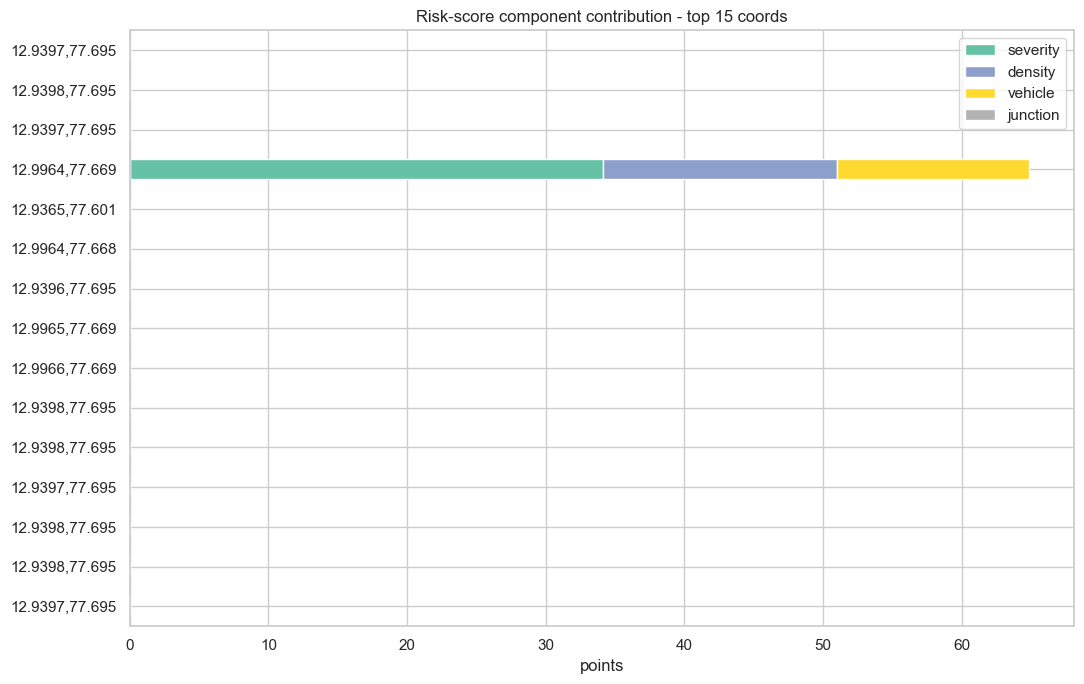

In [11]:
W_SEV, W_DEN, W_VEH, W_JN = 0.40, 0.25, 0.20, 0.15
SEV_NORM = {'PARKING IN A MAIN ROAD': 100, 'PARKING NEAR ROAD CROSSING': 83,
            'PARKING ON FOOTPATH': 67, 'WRONG PARKING': 50, 'NO PARKING': 33}
VEH_NORM = {'SCOOTER': 30, 'MOTOR CYCLE': 30, 'MOPED': 30, 'PASSENGER AUTO': 50, 'GOODS AUTO': 60,
            'CAR': 70, 'JEEP': 70, 'VAN': 75, 'MAXI-CAB': 75, 'TEMPO': 80, 'LGV': 85, 'MINI LORRY': 90,
            'TRACTOR': 90, 'HGV': 100, 'LORRY/GOODS VEHICLE': 100, 'TANKER': 100, 'PRIVATE BUS': 100,
            'BUS (BMTC/KSRTC)': 100}
df_v['sev_n'] = df_v['primary_vtype'].map(SEV_NORM).fillna(33)
df_v['veh_n'] = df_v['vehicle_canon'].map(VEH_NORM).fillna(50)

agg = df_v.groupby('coord').agg(
    count=('id', 'count'), sev=('sev_n', 'mean'), veh=('veh_n', 'mean'),
    jn=('has_junction', 'mean'), lat=('lat', 'first'), lng=('lng', 'first'),
).query('count >= 20')
ref_max = agg['count'].max()
agg['density'] = np.log1p(agg['count']) / np.log1p(ref_max) * 100
agg['jn_input'] = np.where(agg['jn'] >= 0.5, 25, 0)
agg['risk'] = (agg['sev'] * W_SEV + agg['density'] * W_DEN + agg['veh'] * W_VEH + agg['jn_input'] * W_JN).clip(upper=100)

top = agg.sort_values('risk', ascending=False).head(15)
print('Top 15 simulated-risk coordinates:')
print(top[['count', 'sev', 'veh', 'density', 'jn_input', 'risk']].round(1).to_string())

contrib = pd.DataFrame({
    'severity': top['sev'] * W_SEV, 'density': top['density'] * W_DEN,
    'vehicle': top['veh'] * W_VEH, 'junction': top['jn_input'] * W_JN,
}, index=[c[:14] for c in top.index])
ax = contrib.plot(kind='barh', stacked=True, figsize=(11, 7), colormap='Set2')
ax.set_title('Risk-score component contribution - top 15 coords'); ax.set_xlabel('points')
plt.tight_layout(); plt.show()

## E. POI / junction spillover analysis
Keyword-match the officer-logged `location` text into the four production categories.

POI category coverage:
poi_cat
None          266738
commercial     15195
sensitive      14389
transit         1652
metro            308

Tagged: 10.6% of violations


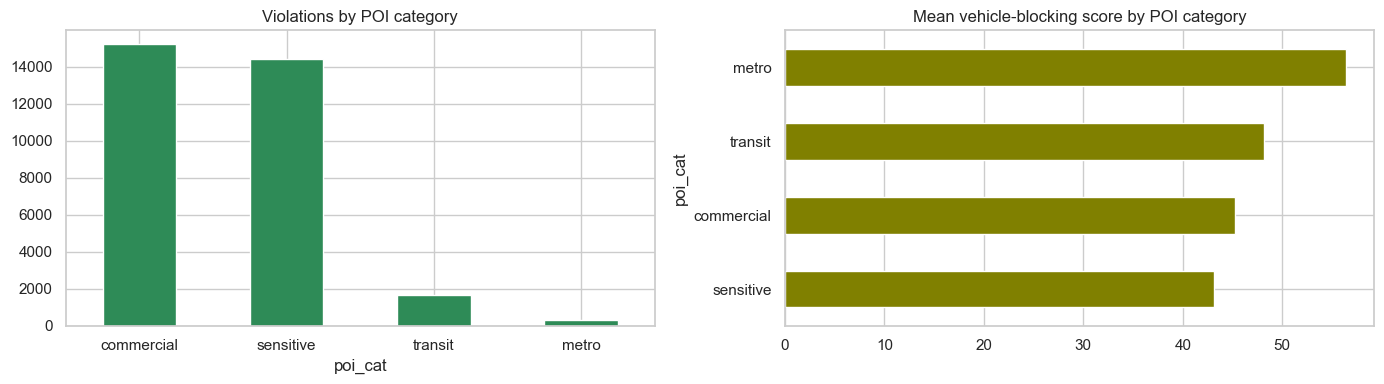

In [12]:
KEYWORDS = {
    'sensitive': ['school', 'college', 'university', 'hospital', 'clinic', 'medical', 'nursing home'],
    'metro':     ['metro', 'railway station', 'rail station'],
    'commercial': ['mall', 'market', 'complex', 'bazaar', 'bazar', 'shopping', 'plaza', 'arcade'],
    'transit':   ['bus stop', 'bus stand', 'bus station', 'bus depot', 'ksrtc', 'bmtc'],
}
PRIORITY = ['sensitive', 'metro', 'commercial', 'transit']
pat = {c: re.compile(r'\b(?:' + '|'.join(re.escape(k) for k in ks) + r')\b', re.I) for c, ks in KEYWORDS.items()}

def classify(text):
    if not isinstance(text, str):
        return None
    for c in PRIORITY:
        if pat[c].search(text):
            return c
    return None

df_v['poi_cat'] = df_v['location'].apply(classify)
print('POI category coverage:')
print(df_v['poi_cat'].value_counts(dropna=False).to_string())
print(f'\nTagged: {df_v["poi_cat"].notna().mean() * 100:.1f}% of violations')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_v['poi_cat'].value_counts().plot(kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title('Violations by POI category'); axes[0].tick_params(axis='x', rotation=0)
df_v.groupby('poi_cat')['veh_n'].mean().sort_values().plot(kind='barh', ax=axes[1], color='olive')
axes[1].set_title('Mean vehicle-blocking score by POI category')
plt.tight_layout(); plt.show()

## F. The afternoon "blind spot" - logging coverage, not demand
README claims near-zero 13:00-16:00 IST logging city-wide. Verify it, and check it holds
**per station** (so it is a systemic shift pattern, not a few stations).

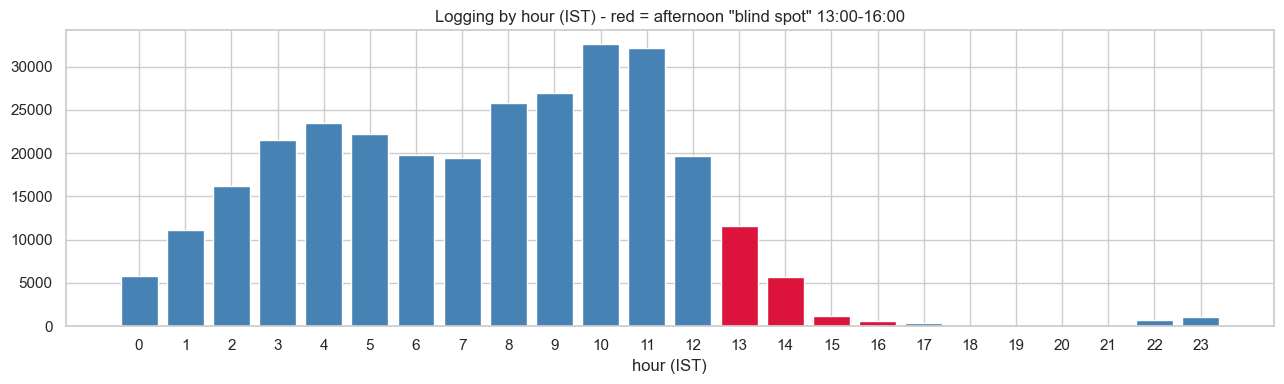

Afternoon (13-16 IST) share city-wide: 6.36%

Stations with >=500 logs: 52
Median afternoon share across stations: 6.08%

Lowest afternoon-coverage stations:
                 total  aft  aft_pct
police_station                      
High ground       4951   69     1.39
Halasuru Gate     6294  138     2.19
Rajajinagar      10998  293     2.66
HAL Old Airport  20819  560     2.69
Vijayanagara     14652  428     2.92
Chamarajpet       3795  117     3.08
Cubbon Park       3255  109     3.35
City Market      17646  596     3.38
Halasur           4011  146     3.64
Sheshadripuram    3090  123     3.98


In [13]:
hourly = df_v['hour'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(13, 4))
colors = ['crimson' if 13 <= h <= 16 else 'steelblue' for h in hourly.index]
ax.bar(hourly.index, hourly.values, color=colors)
ax.set_title('Logging by hour (IST) - red = afternoon "blind spot" 13:00-16:00')
ax.set_xlabel('hour (IST)'); ax.set_xticks(range(0, 24))
plt.tight_layout(); plt.show()

aft = df_v[df_v['hour'].between(13, 16)]
print(f'Afternoon (13-16 IST) share city-wide: {len(aft) / len(df_v) * 100:.2f}%')

stn = df_v.groupby('police_station').agg(
    total=('id', 'count'),
    aft=('hour', lambda s: s.between(13, 16).sum()))
stn['aft_pct'] = (stn['aft'] / stn['total'] * 100).round(2)
stn = stn.query('total>=500').sort_values('aft_pct')
print(f'\nStations with >=500 logs: {len(stn)}')
print(f'Median afternoon share across stations: {stn["aft_pct"].median():.2f}%')
print('\nLowest afternoon-coverage stations:')
print(stn.head(10).to_string())

## Summary of EDA2 findings
Study scratchpad - fill in as you read the outputs above:

- **Severity:** which violation types fall back to DEFAULT weight? (5c warning)
- **Reporters:** how concentrated is logging? (6 top-10 device share)
- **Repeat offenders:** mostly anchored or mobile? (A scatter)
- **Chronic spots:** peak hour per top coordinate (B)
- **Data quality:** which violation/vehicle types get rejected most (C)
- **Risk drivers:** which component dominates top hotspots (D stacked bars)
- **Spillover:** POI tag coverage % and dominant category (E)
- **Blind spot:** confirmed systemic across stations? (F)